<a href="https://colab.research.google.com/github/RohanRanshinge/causal-inference/blob/main/zero-to-hero-bsts/PART_I-Bayesian-Statistics/05.4-Normal-Normal-Conjugate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normal - Normal Conjugate

The Normal-Normal conjugate is the last piece we need before structural time series models like CausalImpact make sense. Every time a local-level model rolls forward one time step, it is quietly doing a Normal-Normal update: yesterday's belief about the level acts as the prior, today's noisy observation acts as the data, and the two combine into an updated belief.

Unlike the Gamma-Poisson pair (estimating a *rate*) or the Normal-Inverse Gamma pair (estimating a *variance*), the Normal-Normal pair estimates a **mean** and it does so under one assumption: the variance is already known

## Normal Distribution: Known Variance, Unknown Mean

The Normal distribution is defined by two parameters, the mean μ and the variance σ²:

$$N(x;\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

For this conjugate pair, we treat **σ² as known** (maybe it comes from a spec sheet, a long history of measurements, or a calibrated instrument) and treat **μ as the unknown we're trying to learn**. That's the opposite split from the Normal-Inverse Gamma notebook, where the mean was known and the variance was the mystery.

Below are three Normal curves with the same known σ but different possible means. We know *roughly* what family the truth belongs to, we just don't know which μ is correct.

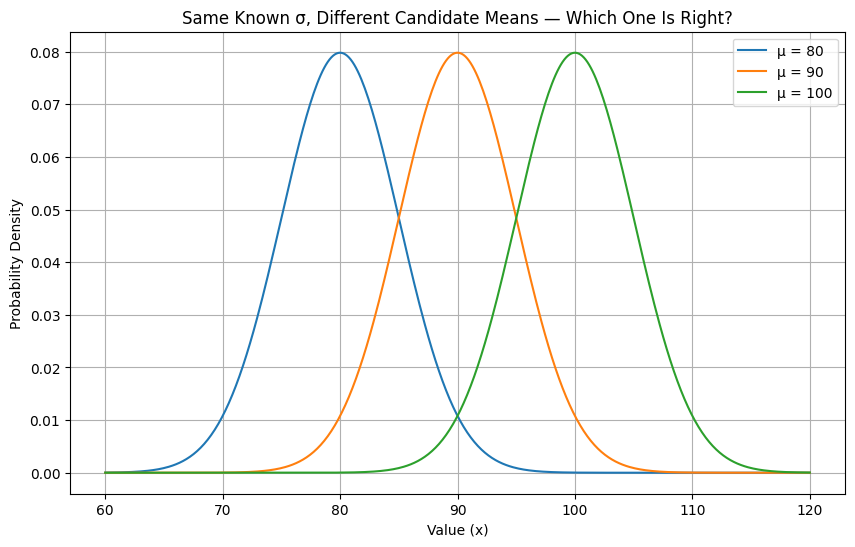

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Same known sigma, three candidate means
sigma = 5
candidate_mus = [80, 90, 100]

x = np.linspace(60, 120, 400)

plt.figure(figsize=(10, 6))
for mu in candidate_mus:
    plt.plot(x, norm.pdf(x, loc=mu, scale=sigma), label=f'μ = {mu}')

plt.title("Same Known σ, Different Candidate Means — Which One Is Right?")
plt.xlabel("Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

### How Fast Is Your Internet, Really?

Your ISP advertises **100 Mbps** download speed on your plan. You've always wondered whether you actually get that, especially during peak hours when demand is highest.

You know from the router manufacturer's published specs that any single speed test has a **measurement noise of σ = 5 Mbps**. That part is known and fixed.

What you don't know is μ: the *true* average speed your connection delivers during peak hours. So one evening, you run 5 back-to-back speed tests:

$$82,\ 90,\ 85,\ 88,\ 79 \text{ Mbps}$$

In [8]:
#| code-fold: false

import numpy as np

data_day1 = np.array([82, 90, 85, 88, 79])
n = len(data_day1)
total = data_day1.sum()
xbar = data_day1.mean()

print(f"n = {n}")
print(f"sum of observations = {total}")
print(f"sample mean x̄ = {xbar:.2f} Mbps")

n = 5
sum of observations = 424
sample mean x̄ = 84.80 Mbps


### How Do We Use a Normal Distribution as a Prior for μ?

μ is a real-valued quantity that can sit anywhere in a range around some expectation - it's not restricted to positive values like a rate or a variance. That symmetric shape is what the Normal distribution offers making it a conjugate prior for a Normal mean.

Before running any tests, your prior belief is anchored on the advertised speed, but you allow for real uncertainty since "advertised" and "actual" rarely match exactly:

$$\mu \sim N(\mu_0 = 100,\ \sigma_0^2 = 15^2)$$

A prior standard deviation of 15 Mbps says you wouldn't be shocked if your true peak-hour speed turned out to be anywhere roughly between 70 and 130 Mbps ($\mu\pm2\sigma$), vague enough to let the data speak.

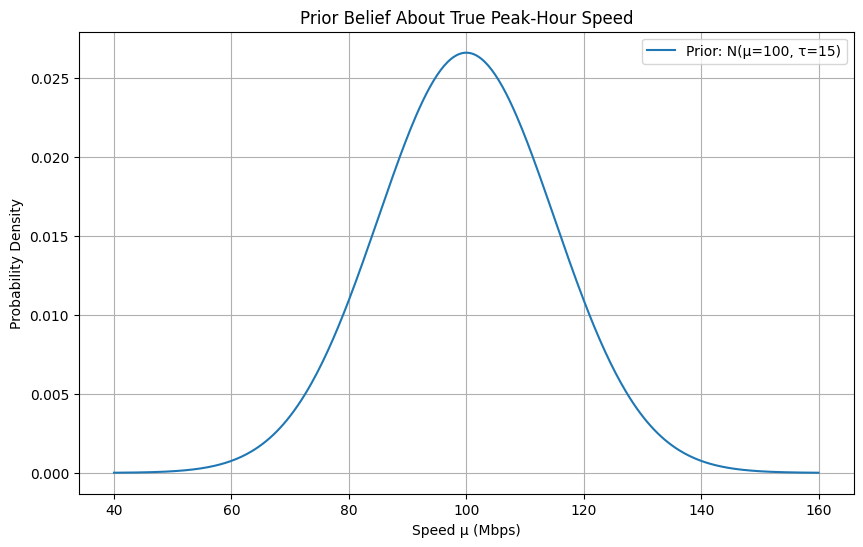

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu_prior = 100
tau_prior = 15

x = np.linspace(40, 160, 400)
pdf_prior = norm.pdf(x, loc=mu_prior, scale=tau_prior)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_prior, label=f'Prior: N(μ={mu_prior}, τ={tau_prior})')

plt.title("Prior Belief About True Peak-Hour Speed")
plt.xlabel("Speed μ (Mbps)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

### Updating with Data: The Normal-Normal Shortcut

Just as Gamma is conjugate to a Poisson likelihood, and Inverse Gamma is conjugate to a Normal's variance, **a Normal prior is conjugate to a Normal likelihood's mean** (when σ² is known). This gives us a closed-form posterior with no integral required.

The cleanest way to see the update is in terms of **precision** (1 / variance). Precision from the prior and precision from the data simply add together:

$$\tau_{pos} = \tau_0 + n*\tau$$

$$\mu_{pos} = \frac{\tau_0\mu_0+\tau\sum x_i}{\tau_0 + n*\tau}$$

Plugging in our numbers: prior N(100, 15²), known σ = 5, n = 5 observations summing to 424:

$$\tau_0 = \frac{1}{15^2} = 0.0044; \tau = \frac{1}{5^2} = 0.04$$

$$\tau_{pos} = \tau_0 + n*\tau = 0.0044 + 5*0.04 = 0.2044$$

$$\mu_{pos} = \frac{\tau_0\mu_0+\tau\sum x_i}{\tau_0 + n*\tau}$$
$$\mu_{pos} = \frac{(0.0044*100)+(0.04*424)}{0.2044} = 85.13$$

Notice how much the data dominates here: the data's precision ($n\tau = 0.2$) is nearly 45× larger than the prior's precision ($\tau_0 = 0.0044$), so the posterior mean lands almost exactly on the sample mean (84.8) rather than the advertised 100.

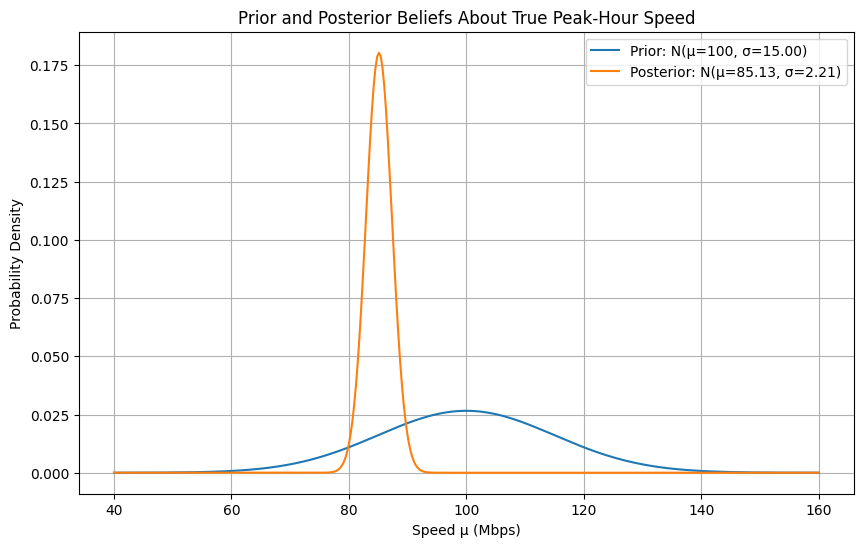

Posterior precision (τ_n): 0.2044
Posterior mean: 85.13 Mbps
Posterior sd:   2.21 Mbps


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

sigma = 5           # known measurement noise (std)
sigma2 = sigma ** 2

mu_prior = 100
sigma_prior = 15
sigma2_prior = sigma_prior ** 2

n = len(data_day1)
total = data_day1.sum()

# Conjugate update, in terms of precision (tau)
tau0 = 1 / sigma2_prior   # prior precision
tau = 1 / sigma2          # per-observation data precision
tau_n = tau0 + n * tau     # posterior precision

mu_post = (tau0 * mu_prior + tau * total) / tau_n
sigma2_post = 1 / tau_n
sigma_post = sigma2_post ** 0.5

x = np.linspace(40, 160, 400)
pdf_prior = norm.pdf(x, loc=mu_prior, scale=sigma_prior)
pdf_post = norm.pdf(x, loc=mu_post, scale=sigma_post)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_prior, label=f'Prior: N(μ={mu_prior}, σ={sigma_prior:.2f})')
plt.plot(x, pdf_post, label=f'Posterior: N(μ={mu_post:.2f}, σ={sigma_post:.2f})')

plt.title("Prior and Posterior Beliefs About True Peak-Hour Speed")
plt.xlabel("Speed μ (Mbps)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

print(f"Posterior precision (τ_n): {tau_n:.4f}")
print(f"Posterior mean: {mu_post:.2f} Mbps")
print(f"Posterior sd:   {sigma_post:.2f} Mbps")

Two things moved in that plot: the posterior **shifted left**, away from the advertised 100 Mbps and toward what the tests actually showed, and it got **much narrower**, because five real observations with a small known noise term (σ = 5) are far more informative than a vague prior guess. You're now fairly confident your real peak-hour speed sits close to 85 Mbps, not the 100 Mbps on the box.

### Sequential Updating: More Tests, More Days

As with the earlier conjugate pairs, the posterior from today becomes the prior for tomorrow. Say you keep testing on two more evenings:

day | tests | readings (Mbps)
:---:|:---:|:---
1 | 5 | 82, 90, 85, 88, 79
2 | 6 | 86, 83, 87, 84, 89, 85
3 | 8 | 84, 86, 85, 83, 87, 85, 84, 86

Each day's posterior rolls forward into the next day's prior.

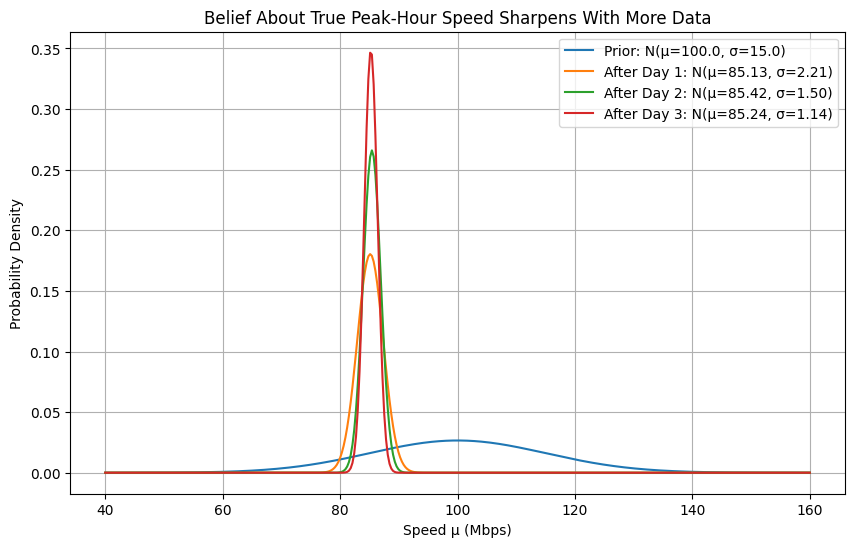

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

batches = [
    np.array([82, 90, 85, 88, 79]),            # Day 1
    np.array([86, 83, 87, 84, 89, 85]),         # Day 2
    np.array([84, 86, 85, 83, 87, 85, 84, 86]), # Day 3
]

mu_prior, sigma2_prior = 100.0, 15.0 ** 2  # start from the original prior
x = np.linspace(40, 160, 400)

plt.figure(figsize=(10, 6))
plt.plot(x, norm.pdf(x, loc=mu_prior, scale=sigma2_prior ** 0.5),
         label=f'Prior: N(μ={mu_prior:.1f}, σ={sigma2_prior**0.5:.1f})')

for i, batch in enumerate(batches, start=1):
    n = len(batch)
    total = batch.sum()

    tau0 = 1 / sigma2_prior   # prior precision
    tau = 1 / sigma2          # per-observation data precision
    tau_n = tau0 + n * tau     # posterior precision

    mu_post = (tau0 * mu_prior + tau * total) / tau_n
    sigma2_post = 1 / tau_n

    plt.plot(x, norm.pdf(x, loc=mu_post, scale=sigma2_post ** 0.5),
             label=f'After Day {i}: N(μ={mu_post:.2f}, σ={sigma2_post**0.5:.2f})')

    # today's posterior becomes tomorrow's prior
    mu_prior, sigma2_prior = mu_post, sigma2_post

plt.title("Belief About True Peak-Hour Speed Sharpens With More Data")
plt.xlabel("Speed μ (Mbps)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

After three days of testing, the posterior has tightened from a 15 Mbps prior standard deviation down to just over 1 Mbps, and it has settled around 85 Mbps and you now have strong grounds to believe your real peak-hour speed runs about 15 Mbps under what's advertised, not just a hunch from one bad test.

Time to change service providers?

### Key Takeaways

The Normal-Normal conjugate pair is used to find an **unknown mean** when the variance is known.

- It applies whenever the quantity you're estimating is real-valued and roughly symmetric (eg: speed,temperature,score, level) and not restricted to positive values like a rate or a variance
- The update is cleanest expressed in **precision** (1/variance): posterior precision is simply prior precision plus data precision
- $$\tau_n = \tau_0 + n*\tau$$
$$\mu_n = \frac{\tau_0\mu_0+\tau\sum x_i}{\tau_0 + n*\tau}$$
- Whichever source is more precise - prior or data - pulls the posterior mean harder toward it. With enough data, the prior's influence fades out almost entirely
- As with Gamma-Poisson and Normal-Inverse Gamma, the posterior stays in the same family as the prior, so there's never an integral to solve

This exact method - a Normal prior on a level, updated by a noisy Normal observation, one time step at a time, is the recursive engine inside the local-level model that CausalImpact builds on. Every step forward in a structural time series is another round of this same update.